# 01. EDA — 선박입출항현황

### 분석 순서
1. 데이터 로드 및 병합 (header=11, 구분=최종 필터)
2. 컬럼 확인 및 COL 딕셔너리 정의
3. **Plan B 확정**: 출항예정일시 없음 → 체류시간 기반 타겟
4. 항만별 분포
5. 체류시간 분포 및 체선 임계값 결정
6. 일별 집계 및 시계열 시각화
7. ACF 분석 (최적 윈도우 크기 검증)
8. 연쇄 혼잡 전이 시간 (Cross-correlation)
9. 결과 저장

---
## 1. 데이터 로드 및 병합

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

RAW_DIR = Path('../data/raw')
files = sorted(RAW_DIR.glob('data_*.xlsx'), key=lambda p: int(p.stem.split('_')[1]))
print(f'파일 수: {len(files)}')
for f in files:
    print(f'  {f.name}')

파일 수: 14
  data_1.xlsx
  data_2.xlsx
  data_3.xlsx
  data_4.xlsx
  data_5.xlsx
  data_6.xlsx
  data_7.xlsx
  data_8.xlsx
  data_9.xlsx
  data_10.xlsx
  data_11.xlsx
  data_12.xlsx
  data_13.xlsx
  data_14.xlsx


In [2]:
# header=11: 앞 11행은 메타정보(제목, 기간, 조건 등)
# 구분=='최종': 최초(첫 입항 기록)/변경(수정 기록) 제외하고 최종 확정 레코드만 사용
dfs = []
for f in files:
    tmp = pd.read_excel(f, dtype=str, header=11)
    tmp['source_file'] = f.name
    dfs.append(tmp)

df_raw = pd.concat(dfs, ignore_index=True)
df_raw = df_raw[df_raw['구분'] == '최종'].copy()
print(f'전체 행 수 (최종 레코드): {len(df_raw):,}')
print(f'전체 열 수: {len(df_raw.columns)}')

/opt/anaconda3/envs/berth_forecast/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


/opt/anaconda3/envs/berth_forecast/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


/opt/anaconda3/envs/berth_forecast/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


/opt/anaconda3/envs/berth_forecast/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


/opt/anaconda3/envs/berth_forecast/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


...

/opt/anaconda3/envs/berth_forecast/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


/opt/anaconda3/envs/berth_forecast/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


/opt/anaconda3/envs/berth_forecast/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


/opt/anaconda3/envs/berth_forecast/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


전체 행 수 (최종 레코드): 692,404
전체 열 수: 29


---
## 2. 컬럼 확인

> 실제 컬럼명: header=11로 로드 후 확인된 값

In [3]:
print('=== 컬럼 목록 ===')
for i, col in enumerate(df_raw.columns.tolist()):
    print(f'  [{i:2d}] {col}')
print()
df_raw.head(2)

=== 컬럼 목록 ===
  [ 0] 항명
  [ 1] 호출부호
  [ 2] 선명
  [ 3] 입항횟수
  [ 4] 입항횟수.1
  [ 5] 구분
  [ 6] 외내
  [ 7] 입출
  [ 8] 총톤수
  [ 9] 입항일시
  [10] 출항일시
  [11] CIQ수속일자
  [12] 수리일시
  [13] 항해구분
  [14] MRN 번호
  [15] 계선장소
  [16] 계선장소.1
  [17] 계선장소.2
  [18] 차항지
  [19] 전출항지
  [20] 선박용도
  [21] 외항:한국인선원수
내항:해기사선원수
  [22] 외항:외국인선원수
내항:보통선원수
  [23] 승객
  [24] 예선
  [25] 도선
  [26] 부선호출부호1
  [27] 부선호출부호2
  [28] source_file



,항명,호출부호,선명,입항횟수,입항횟수.1,구분,외내,입출,총톤수,입항일시,...,전출항지,선박용도,외항:한국인선원수\n내항:해기사선원수,외항:외국인선원수\n내항:보통선원수,승객,예선,도선,부선호출부호1,부선호출부호2,source_file
0,울산,DSAX7,팔도호,2001,001,최종,내항,출항,174,2001-07-15 22:30,...,인천,이.접안용 예선,1,0,0,N,N,NaN,NaN,data_1.xlsx
1,부산,796256,백경3,2004,001,최종,내항,출항,22,2004-01-01 00:00,...,기타항,석유제품 운반선,1,0,0,N,N,NaN,NaN,data_1.xlsx


In [4]:
# 실제 컬럼명 매핑 (header=11 로드 기준)
COL = {
    'port':      '항명',
    'arrive':    '입항일시',
    'depart':    '출항일시',
    'berth':     '계선장소',
    'ship_type': '선박용도',
    'tonnage':   '총톤수',
    'inout':     '외내',
}

for key, col in COL.items():
    exists = col in df_raw.columns
    print(f'  {key:12s} → "{col}" : {"✅" if exists else "❌ 없음"}')

  port         → "항명" : ✅
  arrive       → "입항일시" : ✅
  depart       → "출항일시" : ✅
  berth        → "계선장소" : ✅
  ship_type    → "선박용도" : ✅
  tonnage      → "총톤수" : ✅
  inout        → "외내" : ✅


In [5]:
df = df_raw.copy()

for key in ['arrive', 'depart']:
    col = COL[key]
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

if COL['tonnage'] in df.columns:
    df[COL['tonnage']] = pd.to_numeric(
        df[COL['tonnage']].str.replace(',', '', regex=False), errors='coerce'
    )

# 연구 기간 필터 (입항일시 기준)
STUDY_START = pd.Timestamp('2024-06-20')
STUDY_END   = pd.Timestamp('2026-05-19 23:59')
df = df[
    (df[COL['arrive']] >= STUDY_START) &
    (df[COL['arrive']] <= STUDY_END)
].copy()

print(f'연구 기간 필터 후: {len(df):,}건')
print(f'기간: {df[COL["arrive"]].min()} ~ {df[COL["arrive"]].max()}')
df[[COL['arrive'], COL['depart'], COL['tonnage']]].dtypes

연구 기간 필터 후: 691,036건
기간: 2024-06-20 00:00:00 ~ 2026-05-19 23:55:00


입항일시    datetime64[ns]
출항일시    datetime64[ns]
총톤수            float64
dtype: object

---
## 3. Plan B 확정 — 체류시간 기반 타겟

> `출항예정일시` 컬럼이 존재하지 않으므로 **Plan B** 사용
> 체류시간(출항 - 입항) 90th percentile 초과를 체선으로 정의

In [6]:
has_plan_col = '출항예정일시' in df.columns
print(f'출항예정일시 컬럼 존재 여부: {has_plan_col}')
print('→ Plan B 확정: 항만별 체류시간 90 percentile 초과를 체선으로 정의')
print()
print('=== Plan B 방어 논리 (공모전/발표용) ===')
print('정의: 각 항만에서 통계적으로 비정상적으로 긴 체류 = 체선')
print('근거: 항만마다 정상 운영 범위가 다르므로 항만별 percentile 적용')
print('한계: 10% 고정 발생률 → 발표 시 아래 내용 명시 필요')
print('  · 출항예정일시 부재로 지연시간 직접 계산 불가')
print('  · 90th percentile 기준은 엄밀한 체선 정의 아닌 "상위 10% 장기 체류"')
print('  · 공개 데이터만으로 타겟 생성한 것이 오히려 강점: 재현 가능성 100%')
print('대안 검토: 선박유형별 percentile 적용 → 유형별 정상 체류 시간이 다름')


출항예정일시 컬럼 존재 여부: False
→ Plan B 확정: 항만별 체류시간 90 percentile 초과를 체선으로 정의

=== Plan B 방어 논리 (공모전/발표용) ===
정의: 각 항만에서 통계적으로 비정상적으로 긴 체류 = 체선
근거: 항만마다 정상 운영 범위가 다르므로 항만별 percentile 적용
한계: 10% 고정 발생률 → 발표 시 아래 내용 명시 필요
  · 출항예정일시 부재로 지연시간 직접 계산 불가
  · 90th percentile 기준은 엄밀한 체선 정의 아닌 "상위 10% 장기 체류"
  · 공개 데이터만으로 타겟 생성한 것이 오히려 강점: 재현 가능성 100%
대안 검토: 선박유형별 percentile 적용 → 유형별 정상 체류 시간이 다름


---
## 4. 항만별 분포 및 타겟 항만 필터링

In [7]:
print(f'전체 항만 수: {df[COL["port"]].nunique()}')
print()
print('상위 20개 항만:')
print(df[COL['port']].value_counts().head(20).to_string())

전체 항만 수: 43

상위 20개 항만:
항명
부산      168432
울산       88616
인천       54665
광양       43139
여천       41344
여수       39468
평택       36275
대산       23449
마산       21198
제주       20154
대불분실     20076
군산       14748
목포       13107
포항신항     12324
옥포       10779
동해       10160
고현        7952
진해        7610
서귀포       7367
완도        6128


In [8]:
TARGET_PORTS = ['부산', '울산', '인천', '광양']

df_target = df[df[COL['port']].isin(TARGET_PORTS)].copy()
print(f'타겟 항만 정확 매칭 후: {len(df_target):,}건')
print(df_target[COL['port']].value_counts().to_string())
print()
print('선박용도 상위 분포:')
print(df_target[COL['ship_type']].value_counts().head(15).to_string())
print()
print('외내항 분포:')
print(df_target[COL['inout']].value_counts().to_string())

타겟 항만 정확 매칭 후: 354,852건


항명
부산    168432
울산     88616
인천     54665
광양     43139

선박용도 상위 분포:
선박용도
석유제품 운반선    100837
풀컨테이너선       74573
일반화물선        30800
견인용예선        23496
산물선(벌크선)     16545
기타 예선        13655
케미칼 운반선      13127
급유선          12052
기타 유조선        7597
자동차운반선        6967
기타선           6395
국제카페리         5962
여객선           5506
시멘트운반선        5274
원양 어선         4624

외내항 분포:
외내
내항    184846
외항    170006


---
## 5. 타겟 변수 생성 및 체선 임계값 결정

In [9]:
df_target = df_target.copy()
df_target['체류시간_시간'] = (
    df_target[COL['depart']] - df_target[COL['arrive']]
).dt.total_seconds() / 3600

# 이상치 제거: 음수 체류시간, 999시간(약 42일) 초과
neg = (df_target['체류시간_시간'] < 0).sum()
extreme = (df_target['체류시간_시간'] > 999).sum()
print(f'음수 체류시간: {neg:,}건')
print(f'999h 초과: {extreme:,}건')

df_clean = df_target[
    (df_target['체류시간_시간'] >= 0) &
    (df_target['체류시간_시간'] <= 999)
].copy()
print(f'정제 후: {len(df_clean):,}건')

음수 체류시간: 3건
999h 초과: 2,484건


정제 후: 352,365건


In [10]:
print('=== 체류시간 분포 (항만 전체) ===')
for p in [50, 75, 80, 85, 90, 95, 99]:
    val = df_clean['체류시간_시간'].quantile(p / 100)
    print(f'  {p}th percentile: {val:.2f}시간')

print()
print('=== 항만별 90th percentile ===')
for port in TARGET_PORTS:
    sub = df_clean[df_clean[COL['port']] == port]['체류시간_시간']
    p90 = sub.quantile(0.90)
    print(f'  {port}: {p90:.2f}시간 (n={len(sub):,})')

=== 체류시간 분포 (항만 전체) ===
  50th percentile: 21.10시간
  75th percentile: 47.42시간


  80th percentile: 59.75시간
  85th percentile: 77.75시간
  90th percentile: 108.58시간
  95th percentile: 177.42시간
  99th percentile: 439.45시간

=== 항만별 90th percentile ===
  부산: 113.50시간 (n=166,571)
  울산: 100.33시간 (n=88,371)
  인천: 110.22시간 (n=54,345)


  광양: 111.67시간 (n=43,078)


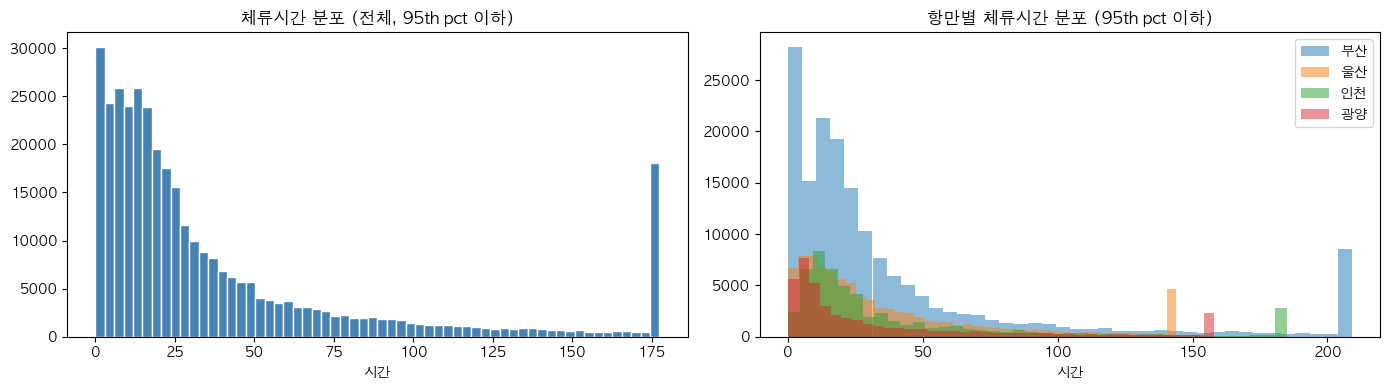

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

stay_clip = df_clean['체류시간_시간'].clip(upper=df_clean['체류시간_시간'].quantile(0.95))
axes[0].hist(stay_clip, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('체류시간 분포 (전체, 95th pct 이하)')
axes[0].set_xlabel('시간')

for port in TARGET_PORTS:
    sub = df_clean[df_clean[COL['port']] == port]['체류시간_시간']
    sub_clip = sub.clip(upper=sub.quantile(0.95))
    axes[1].hist(sub_clip, bins=40, alpha=0.5, label=port)
axes[1].set_title('항만별 체류시간 분포 (95th pct 이하)')
axes[1].set_xlabel('시간')
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
# Plan B: 항만별 체류시간 90 percentile 초과를 체선으로 정의
port_p90 = (
    df_clean.groupby(COL['port'])['체류시간_시간']
    .quantile(0.90)
    .rename('threshold_90p')
    .reset_index()
)
print('항만별 체선 임계값 (90th percentile):')
print(port_p90.to_string(index=False))

df_clean = df_clean.merge(port_p90, on=COL['port'], how='left')
df_clean['체선여부'] = (df_clean['체류시간_시간'] > df_clean['threshold_90p']).astype(int)

print()
print('=== 항만별 체선 발생률 ===')
for port in TARGET_PORTS:
    sub = df_clean[df_clean[COL['port']] == port]
    rate = sub['체선여부'].mean() * 100
    print(f'  {port}: {rate:.1f}% ({sub["체선여부"].sum():,}/{len(sub):,}건)')

항만별 체선 임계값 (90th percentile):
항명  threshold_90p
광양     111.666667
부산     113.500000
울산     100.333333
인천     110.216667

=== 항만별 체선 발생률 ===
  부산: 10.0% (16,656/166,571건)


  울산: 10.0% (8,834/88,371건)
  인천: 10.0% (5,435/54,345건)
  광양: 10.0% (4,307/43,078건)


---
## 6. 일별 집계 및 시계열 시각화

In [13]:
df_clean['date'] = df_clean[COL['arrive']].dt.normalize()

# 선박유형 그룹핑
SHIP_GROUPS = {
    '컨테이너': ['풀컨테이너선', '반컨테이너선'],
    '유조선':   ['석유제품 운반선', '원유운반선', '케미칼 운반선', '기타 유조선'],
    '벌크':     ['산물선(벌크선)', '시멘트운반선', '광석운반선'],
    '일반화물': ['일반화물선', '다목적화물선'],
}

def ship_ratio(df_grp, types):
    return df_grp[COL['ship_type']].isin(types).mean()

agg_dict = {
    '입항수':     ('date', 'count'),
    '평균체류시간': ('체류시간_시간', 'mean'),
    '체선율':     ('체선여부', 'mean'),
}

daily = df_clean.groupby([COL['port'], 'date']).agg(**agg_dict).reset_index()

# 선박유형 비율 추가
for group, types in SHIP_GROUPS.items():
    ratio = (
        df_clean.groupby([COL['port'], 'date'])
        .apply(lambda g: g[COL['ship_type']].isin(types).mean(), include_groups=False)
        .reset_index(name=f'{group}_비율')
    )
    daily = daily.merge(ratio, on=[COL['port'], 'date'], how='left')

print(f'일별 집계 행 수: {len(daily):,}')
print(f'컬럼: {daily.columns.tolist()}')
daily.head()

일별 집계 행 수: 1,407
컬럼: ['항명', 'date', '입항수', '평균체류시간', '체선율', '컨테이너_비율', '유조선_비율', '벌크_비율', '일반화물_비율']


,항명,date,입항수,평균체류시간,체선율,컨테이너_비율,유조선_비율,벌크_비율,일반화물_비율
0,광양,2024-06-20,62,39.075806,0.129032,0.387097,0.032258,0.193548,0.161290
1,광양,2024-06-21,92,39.724275,0.021739,0.369565,0.108696,0.086957,0.282609
2,광양,2024-06-22,64,35.117708,0.125000,0.343750,0.156250,0.156250,0.156250
3,광양,2024-06-23,48,20.666667,0.000000,0.333333,0.208333,0.166667,0.125000
4,광양,2024-06-24,68,29.476961,0.058824,0.205882,0.205882,0.147059,0.147059


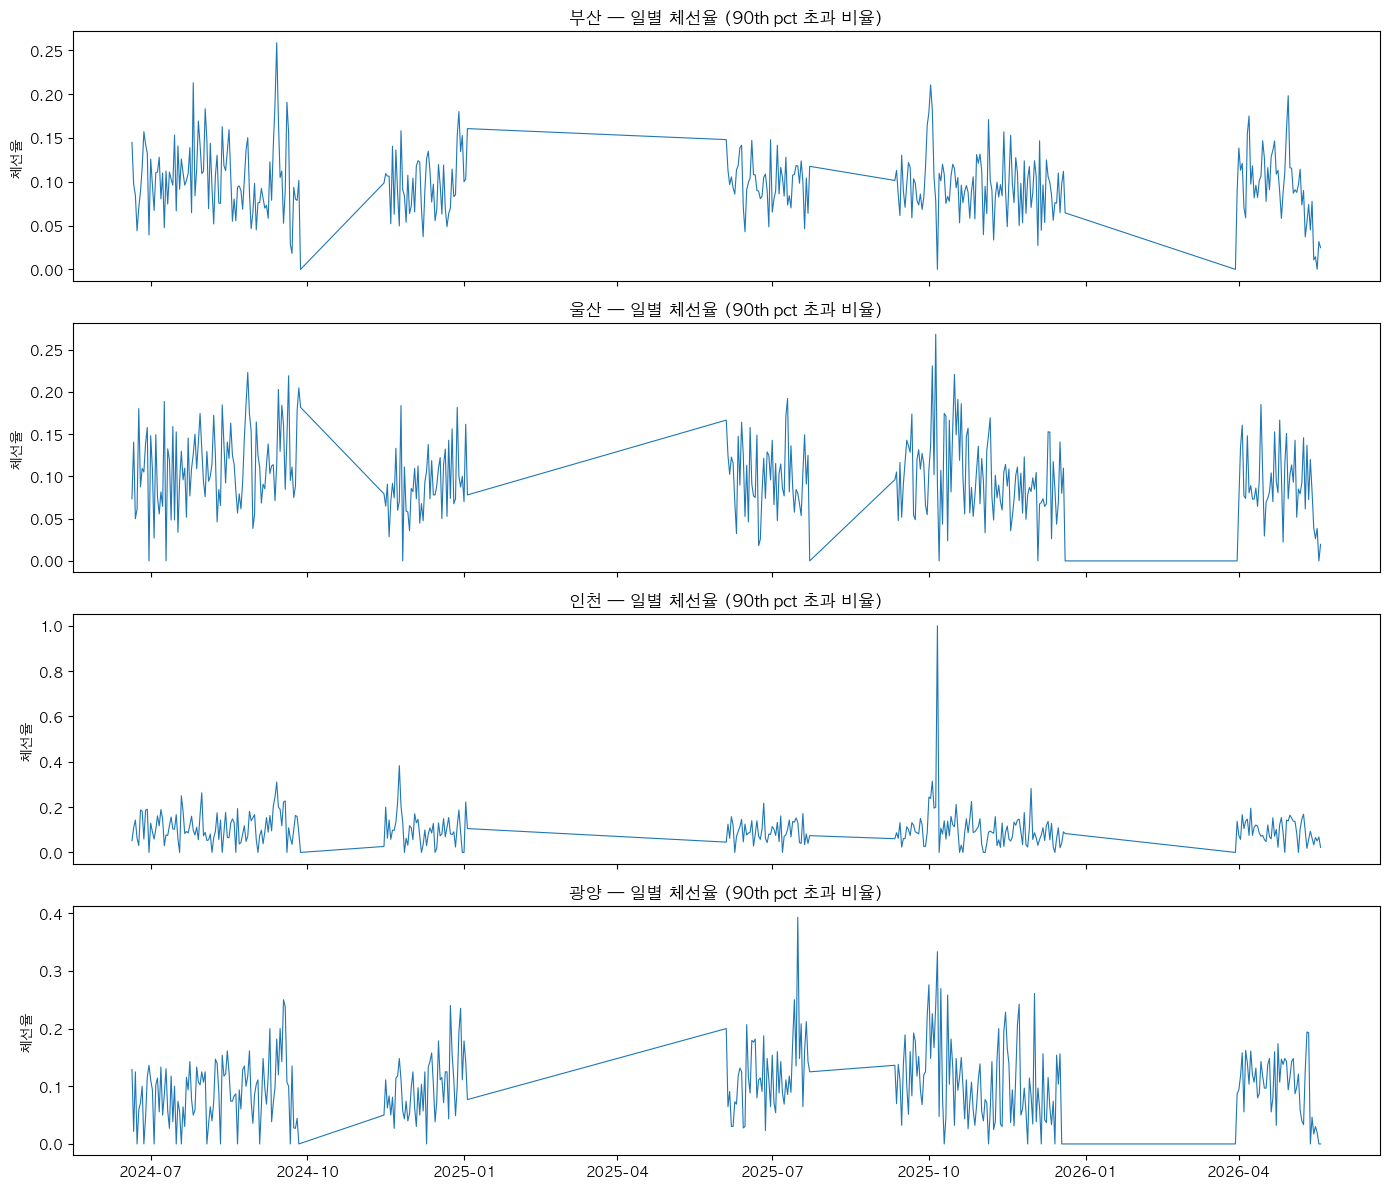

In [14]:
fig, axes = plt.subplots(len(TARGET_PORTS), 1, figsize=(14, 3 * len(TARGET_PORTS)), sharex=True)

for i, port in enumerate(TARGET_PORTS):
    port_data = daily[daily[COL['port']] == port].sort_values('date')
    if len(port_data) == 0:
        axes[i].set_title(f'{port} — 데이터 없음')
        continue
    axes[i].plot(port_data['date'], port_data['체선율'], linewidth=0.8)
    axes[i].set_title(f'{port} — 일별 체선율 (90th pct 초과 비율)')
    axes[i].set_ylabel('체선율')

plt.tight_layout()
plt.show()

---
## 7. ACF 분석 (최적 윈도우 크기 검증)

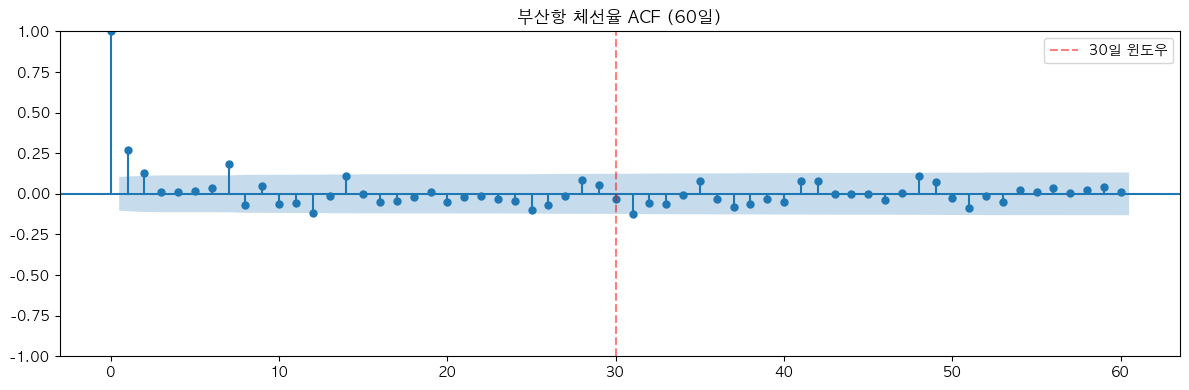

In [15]:
from statsmodels.graphics.tsaplots import plot_acf

busan = daily[daily[COL['port']] == '부산'].sort_values('date')
busan_series = busan['체선율'].fillna(0).values

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(busan_series, lags=60, ax=ax)
ax.set_title('부산항 체선율 ACF (60일)')
ax.axvline(x=30, color='red', linestyle='--', alpha=0.5, label='30일 윈도우')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. 연쇄 혼잡 전이 시간 (Cross-correlation)

> 이 결과가 Transformer lag 피처 설계의 근거

In [16]:
from statsmodels.tsa.stattools import ccf

def get_port_series(port_name):
    data = daily[daily[COL['port']] == port_name]
    data = data.set_index('date')['체선율']
    full_idx = pd.date_range(data.index.min(), data.index.max(), freq='D')
    return data.reindex(full_idx).ffill().fillna(0)

def calc_cascade_lag(series_a, series_b, max_lag=14, label_a='A', label_b='B'):
    common = series_a.index.intersection(series_b.index)
    if len(common) < 30:
        print(f'  {label_a} → {label_b}: 공통 기간 부족 (n={len(common)})')
        return None, None
    corrs = ccf(series_a.loc[common].values, series_b.loc[common].values,
                nlags=max_lag, adjusted=True)
    lag = int(np.argmax(np.abs(corrs[1:max_lag+1]))) + 1
    print(f'  {label_a} → {label_b}: {lag}일 후 전이 (상관계수: {corrs[lag]:.3f})')
    return lag, corrs[lag]

print('=== 항만 간 연쇄 혼잡 전이 시간 ===')
series = {}
for p in TARGET_PORTS:
    if p in daily[COL['port']].values:
        series[p] = get_port_series(p)

cascade_results = {}
for a, b in [('부산', '울산'), ('부산', '광양'), ('부산', '인천'), ('울산', '광양')]:
    if a in series and b in series:
        lag, corr = calc_cascade_lag(series[a], series[b], label_a=a, label_b=b)
        if lag is not None:
            cascade_results[(a, b)] = {'lag': lag, 'corr': corr}

=== 항만 간 연쇄 혼잡 전이 시간 ===
  부산 → 울산: 2일 후 전이 (상관계수: -0.180)
  부산 → 광양: 1일 후 전이 (상관계수: 0.384)
  부산 → 인천: 1일 후 전이 (상관계수: 0.339)
  울산 → 광양: 1일 후 전이 (상관계수: 0.128)


---
## 9. 결과 저장

In [17]:
PROCESSED = Path('../data/processed')
PROCESSED.mkdir(exist_ok=True)

df_clean.to_csv(PROCESSED / 'vessel_clean.csv', index=False, encoding='utf-8-sig')
daily.to_csv(PROCESSED / 'daily_aggregated.csv', index=False, encoding='utf-8-sig')

print('저장 완료')
print('  → data/processed/vessel_clean.csv')
print('  → data/processed/daily_aggregated.csv')
print(f'  daily 컬럼: {daily.columns.tolist()}')
print()
print('=== EDA 최종 요약 ===')
print(f'전체 데이터   : {len(df_raw):,}건 (최종 레코드, 연구기간 필터 전)')
print(f'연구기간 필터  : {len(df):,}건')
print(f'타겟 항만     : {len(df_target):,}건')
print(f'정제 후       : {len(df_clean):,}건')
print(f'타겟 변수     : Plan B — 체류시간 90th percentile 초과 → 체선')
print(f'연쇄 전이 시간: ', {f"{a}→{b}": v["lag"] for (a,b),v in cascade_results.items()})
print(f'선박유형 피처  : {[g+"_비율" for g in SHIP_GROUPS]}')

저장 완료
  → data/processed/vessel_clean.csv
  → data/processed/daily_aggregated.csv
  daily 컬럼: ['항명', 'date', '입항수', '평균체류시간', '체선율', '컨테이너_비율', '유조선_비율', '벌크_비율', '일반화물_비율']

=== EDA 최종 요약 ===
전체 데이터   : 692,404건 (최종 레코드, 연구기간 필터 전)
연구기간 필터  : 691,036건
타겟 항만     : 354,852건
정제 후       : 352,365건
타겟 변수     : Plan B — 체류시간 90th percentile 초과 → 체선
연쇄 전이 시간:  {'부산→울산': 2, '부산→광양': 1, '부산→인천': 1, '울산→광양': 1}
선박유형 피처  : ['컨테이너_비율', '유조선_비율', '벌크_비율', '일반화물_비율']
